In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Review : multiplying vectors
a_vector = np.array([1,2,3,4,5]) # 1x5 arrays
b_vector = np.array([6,7,8,9,10]) 

a_vector * b_vector  # pairwise multiplication - must be exact shapes

array([ 6, 14, 24, 36, 50])

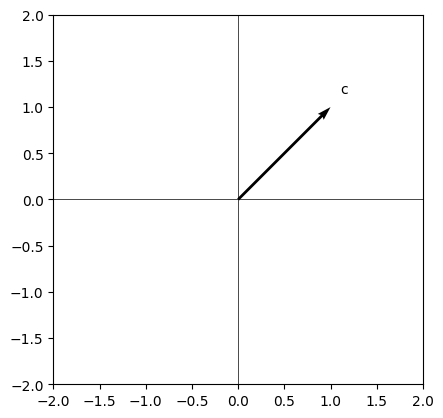

In [2]:
# The Dot Product

# Another way to combine two vectors is to take the dot product. 
# The dot product is sometimes used to express how much two vectors are "pointing" in the same direction.

c_vector = np.array([1,1])
d_vector = np.array([0.785,1.176])
e_vector = np.array([-1, 1])
f_vector = np.array([-0.785,-1.176])

# a function for making a blank set of axes for plotting
def make_axes():
    plt.axvline(0, color='black', lw=0.5)
    plt.axhline(0, color='black', lw=0.5)
    # Scale the plot 
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.gca().set_aspect('equal', adjustable='box')
    fig = plt.gca()
    return fig

# function for adding a vector to a plot
def add_vector_to_figure(figure, v, color='black', label=None):
    origin = np.array([0,0])
    figure.quiver(*origin, *v, scale=1, scale_units='xy', angles='xy', color=color)
    if label is not None:
        figure.annotate(label, v, textcoords="offset points", xytext=(10,10), ha='center')


# create a empty plot with axes and add the c_vector
empty_fig = make_axes()
add_vector_to_figure(empty_fig, c_vector, label='c')

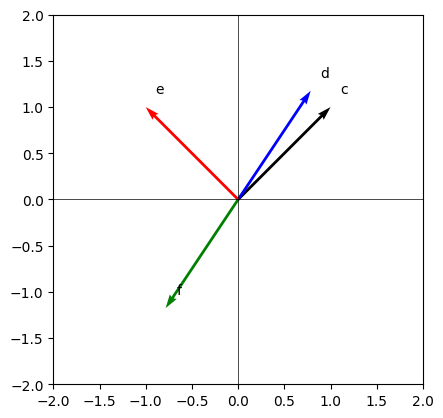

In [3]:
empty_fig  = make_axes()
add_vector_to_figure(empty_fig, c_vector, label = "c")
add_vector_to_figure(empty_fig, d_vector, color='blue', label = "d")
add_vector_to_figure(empty_fig, e_vector, color='red', label = "e")
add_vector_to_figure(empty_fig, f_vector, color='green', label = "f")

In [4]:
# Looking at the vectors above- which two vectors do we think are most similar? Now let's compute some dot products. 
# The dot products of 2 vectors a and b is  abs(a).abs(b).cos(alpha) where alpha is the angle between a and b.
print(f"dot product of c and d: {np.dot(c_vector, d_vector):.2f}") 
print(f"dot product of c and e: {np.dot(c_vector, e_vector):.2f}")
print(f"dot product of c and c: {np.dot(c_vector, c_vector):.2f}")
print(f"dot product of d and f: {np.dot(d_vector, f_vector):.2f}")
print(f"dot product of c and f: {np.dot(c_vector, f_vector):.2f}")


dot product of c and d: 1.96
dot product of c and e: 0.00
dot product of c and c: 2.00
dot product of d and f: -2.00
dot product of c and f: -1.96


In [5]:
# Word Vectors

# One real application of the dot product is determining similarities between text embeddings. 
# Text embeddings are one of the most important ideas in modern natural language processing- essentially, the concept 
# is that we can represent text as coordinates in space. And strings of text that are used in similar contexts are neighbors.

from sentence_transformers import SentenceTransformer, util

sentences = ["The Amazon rainforest is home to many species of animals.",
            "Neil Armstrong walked on the moon in 1969.",
            "The forecast is cloudy with a chance of rain.",
            "Doctors recommend drinking plenty of water.",
            "The eagle soared high above the mountain peaks."
]

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences) # transform sentences to embeddings
print(f"\n\nembedings.shape : {embeddings.shape}")
print(f"embedings :\n {embeddings}")

target = "Do you think I should bring an umbrella to work?"
target_embedding = model.encode(target)

# Now we can calculate the dot product for each of the sentences with the target embedding.
dot_products = np.dot(embeddings, target_embedding)
print(f"\ndot_products :\n {dot_products}" )

# Finally, we can return the sentence with the highest dot product with the target.
most_similar_sentence = sentences[np.argmax(dot_products)]
print(f"\nMost similar sentence :\n {most_similar_sentence}")

# target score
score = util.cos_sim(embeddings[np.argmax(dot_products)], target_embedding)
print(f" target score: {score.item() * 100:.4f} %")


/home/samlau/Python/StatisticsWithPython/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1517.02it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.




embedings.shape : (5, 384)
embedings :
 [[ 0.1034089  -0.02176801  0.0033615  ... -0.00890594  0.02649778
   0.07595526]
 [-0.00509504  0.05921377 -0.00858602 ...  0.0422514  -0.06364243
  -0.05060041]
 [-0.03826974 -0.02389531  0.14726311 ... -0.03116696 -0.09609795
   0.05026631]
 [ 0.04123136  0.02932179  0.03853342 ...  0.01740015  0.05582331
   0.03744821]
 [-0.05162054  0.08256526 -0.03449445 ... -0.02360644 -0.01241299
   0.01232052]]

dot_products :
 [0.04031001 0.07074854 0.30641502 0.14015168 0.09861268]

Most similar sentence :
 The forecast is cloudy with a chance of rain.
 target score: 30.6415 %


In [6]:
# Compute similarity
# Comparing sentence 0 and 1 (Amazon forest) vs 2 and 3 (weather)
score1 = util.cos_sim(embeddings[0], embeddings[1])
score2 = util.cos_sim(embeddings[2], embeddings[3])

print(f"Amazon forest similarity: {score1.item():.4f}")
print(f"Weather similarity: {score2.item():.4f}")

Amazon forest similarity: -0.0443
Weather similarity: 0.1490


In [7]:
# Matrix Multiplication

# We can do operations like multiplication on arrays via broadcasting, in which we stratch one array so we can perform element-by-element multiplication.
array_a = np.array([[1,0],[0,1]]) # 2x2 array
array_b = np.array([1,2])         # 1x2 array

array_a * array_b  # result in 2x2 array


array([[1, 0],
       [0, 2]])

In [8]:
# In many advanced data science techniques, we use an operation called matrix multiplication - which is not the same as the operation shown above!
np.matmul(array_a, array_b)  # result in 1x2 array
array_a @ array_b            # does exactly the same as above line, shortcut

array([1, 2])

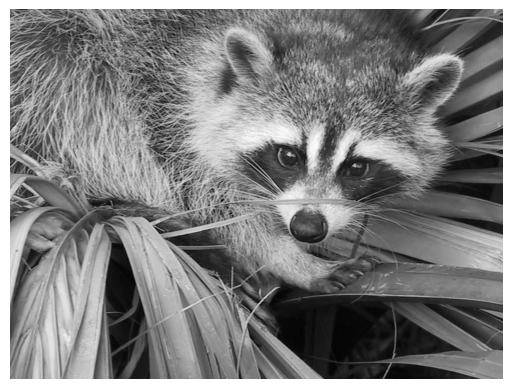

In [9]:
# What can we use matrix multiplication for?
# Matrix multiplication is used in so many types of computations- one of the most immediately rewarding is for transforming images. 
# We can use matrix multiplication to rotate a picture, for example.

import matplotlib.pyplot as plt
from scipy import datasets

# Load the raccoon face (gray=True for 2D array, False for 3D/Color)
face = datasets.face(gray=True)

# Set the colormap to gray and display
plt.imshow(face, cmap='gray')
plt.axis('off') # Optional: hides the pixel coordinates
plt.show()      # Required if running as a .py script


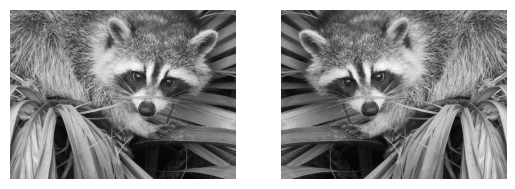

In [12]:
# We define a transformation matrix.
transform = np.rot90(np.eye(1024))

# then we multiply our image matrix by the transformation matrix
transformed_face = face @ transform

# plotting the orginal image and the result side by side
plt.subplot(1, 2, 1)
plt.axis('off')
plt.imshow(face, cmap='gray')
plt.subplot(1, 2, 2)
plt.axis('off')
plt.imshow(transformed_face, cmap='gray')


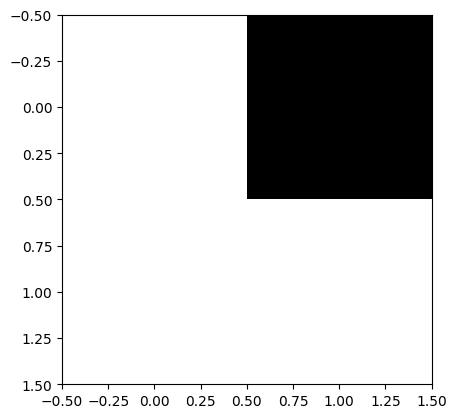

In [14]:
# How did we transform the image? Let's consider a much tinier and simple image.

tiny_image = np.array([[1,0],[1,1]])
plt.imshow(tiny_image, cmap='gray')

In [ ]:
tiny_transform = np.rot90(np.eye(2))
tiny_transform # transform the matrix from [[1,0],[1,1]] to [[0,1],[1,0]]

array([[0., 1.],
       [1., 0.]])

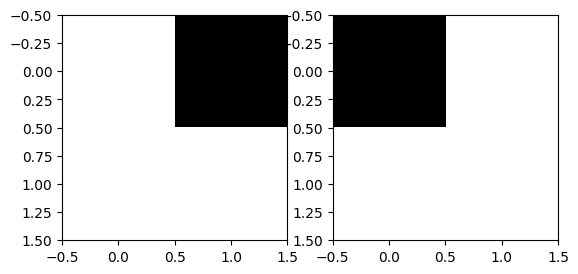

In [16]:
# Let's do the computation and show it
transformed_tiny_image = tiny_image @ tiny_transform

plt.subplot(1, 2, 1)
plt.imshow(tiny_image, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(transformed_tiny_image, cmap='gray')

In [17]:
# One way to think of matrix multiplication is as applying a transformation to our data. When we multiply our image array by transform, we modify the image in a predictable way!

# Although you may rarely have to do matrix multiplication by hand, it is used "under the hood" in a huge variety of applications:
#     implementing neural networks
#     estimating a linear regression model
#     dimensionality reduction techniques



In [18]:
# Matrix multiplication rules
# As is often the case, we have to be mindful about the properties of arrays we are operating on. 
array_c = np.ones((4, 4))
array_d = np.ones((10, 1))
array_e = np.ones((2,4))
array_f = np.ones((4, 1))


In [19]:
array_c @ array_d

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 10 is different from 4)

In [20]:
array_c @ array_e

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 4)

In [21]:
array_c @ array_f

array([[4.],
       [4.],
       [4.],
       [4.]])